# 05. 부록 데이터 살펴보기 (Appendix E / F)

저장소에 포함된 두 개의 엑셀 파일은 **실제 논문 모델**이 만든 운영 로그입니다. 학습 코드는 비공개지만, 이 로그로 학습된 정책이 어떻게 운영하는지 볼 수 있습니다.

* `AppE_ExtremeStressEval_C2Square_R1_Episode2.xlsx` — `C2_Square_R1` 모델의 **극한 스트레스 테스트**(30년 = 10,950일) 일별 로그와 요약
* `AppF_CrossReservoir_DecisionLogs_Public_Xiluodu_Xiangjiaba.xlsx` — 다른 두 저수지(시뤄두, 샹자바)에 적용한 **교차 저수지 검증** 5년 로그

시트/열 이름은 중국어이므로 영문으로 바꿔서 봅니다.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "tutorial_nbs" else Path.cwd()
plt.rcParams["figure.figsize"] = (12, 3.4)
APP_E = ROOT / "AppE_ExtremeStressEval_C2Square_R1_Episode2.xlsx"
APP_F = ROOT / "AppF_CrossReservoir_DecisionLogs_Public_Xiluodu_Xiangjiaba.xlsx"

## 1. Appendix E — 일별 로그

In [2]:
COLS_E = ["day", "level_m", "tailwater_m", "storage_1e8m3", "inflow", "outflow", "turbine_flow", "spill_flow", "energy_1e8kWh",
          "guaranteed_output_flag", "water_balance", "agent_action", "actual_action", "mask_min_action", "mask_max_action", "action_violation",
          "reward", "power_reward", "level_penalty", "flood_penalty", "ecological_penalty", "powerlimit_penalty", "navigation_penalty", "action_penalty",
          "obs_level", "obs_inflow", "obs_future_inflow", "obs_upper_limit_level", "obs_doy_sin", "obs_doy_cos"]
xl = pd.ExcelFile(APP_E)
daily = xl.parse(xl.sheet_names[0])          # first sheet: daily log
daily.columns = COLS_E[:daily.shape[1]]
daily["year"] = daily.day // 365; daily["doy"] = daily.day % 365 + 1
print(daily.shape, "->", daily.day.max() + 1, "days =", (daily.day.max() + 1) / 365, "years")
daily.head()

(10950, 32) -> 10950 days = 30.0 years


,day,level_m,tailwater_m,storage_1e8m3,inflow,outflow,turbine_flow,spill_flow,energy_1e8kWh,guaranteed_output_flag,...,navigation_penalty,action_penalty,obs_level,obs_inflow,obs_future_inflow,obs_upper_limit_level,obs_doy_sin,obs_doy_cos,year,doy
0,0,175.000000,63.285961,393.000000,5905.881204,6638.777535,6638.777535,0.0,1.483752,0,...,0.0,0.0,1.000000,0.126245,0.130432,1.0,0.586824,0.992404,0,1
1,1,174.931271,63.285961,392.376590,5965.681297,6638.777535,6638.777535,0.0,1.482871,0,...,0.0,0.0,0.997709,0.127523,0.133000,1.0,0.586824,0.992404,0,2
2,2,174.867301,63.285961,391.820987,6433.641433,6638.777535,6638.777535,0.0,1.482333,0,...,0.0,0.0,0.995577,0.137526,0.134984,1.0,0.586824,0.992404,0,3
3,3,174.850238,63.285961,391.674206,6266.303220,6638.777535,6638.777535,0.0,1.482001,0,...,0.0,0.0,0.995008,0.133949,0.134055,1.0,0.586824,0.992404,0,4
4,4,174.817360,63.285961,391.390742,6244.172144,6638.777535,6638.777535,0.0,1.481556,0,...,0.0,0.0,0.993912,0.133476,0.132599,1.0,0.586824,0.992404,0,5


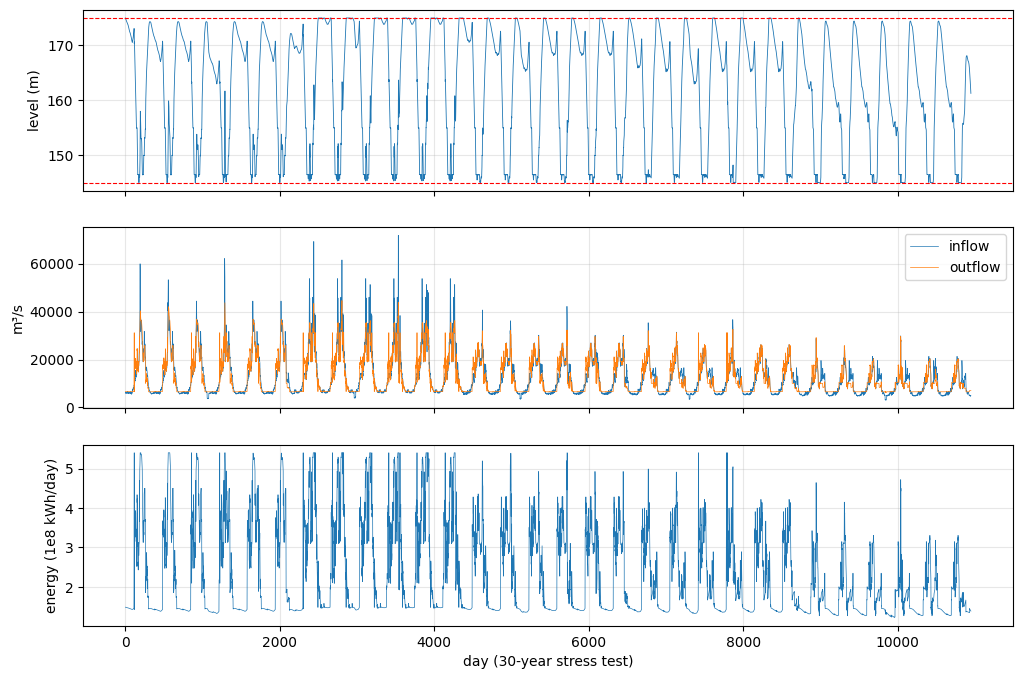

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily.day, daily.level_m, lw=.6); axes[0].axhline(175, c="r", ls="--", lw=.8); axes[0].axhline(145, c="r", ls="--", lw=.8); axes[0].set_ylabel("level (m)")
axes[1].plot(daily.day, daily.inflow, lw=.5, label="inflow"); axes[1].plot(daily.day, daily.outflow, lw=.5, label="outflow"); axes[1].legend(); axes[1].set_ylabel("m³/s")
axes[2].plot(daily.day, daily.energy_1e8kWh, lw=.5); axes[2].set_ylabel("energy (1e8 kWh/day)"); axes[2].set_xlabel("day (30-year stress test)")
for a in axes: a.grid(alpha=.3)

### 연도별 평균 운영 패턴

30년 로그를 일(day-of-year) 기준으로 겹쳐 보면 정책이 학습한 **연간 운영 규칙**(홍수기 전 수위 저하 → 홍수기 후 담수)이 드러납니다.

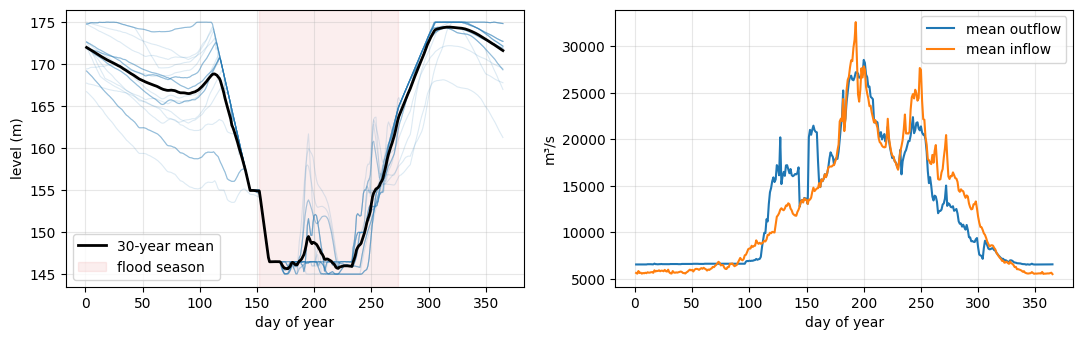

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
piv = daily.pivot_table(index="doy", columns="year", values="level_m")
axes[0].plot(piv.index, piv.values, c="tab:blue", alpha=.15, lw=.8); axes[0].plot(piv.index, piv.mean(axis=1), c="k", lw=2, label="30-year mean")
axes[0].axvspan(152, 273, color="tab:red", alpha=.08, label="flood season"); axes[0].set_xlabel("day of year"); axes[0].set_ylabel("level (m)"); axes[0].legend()
piv2 = daily.pivot_table(index="doy", columns="year", values="outflow")
axes[1].plot(piv2.index, piv2.mean(axis=1), label="mean outflow"); axes[1].plot(piv2.index, daily.pivot_table(index="doy", columns="year", values="inflow").mean(axis=1), label="mean inflow")
axes[1].set_xlabel("day of year"); axes[1].set_ylabel("m³/s"); axes[1].legend()
for a in axes: a.grid(alpha=.3)

### 액션 마스크와 액션 보정

`mask_min_action` / `mask_max_action` 은 그날 허용된 액션 범위(FullMask), `agent_action` 은 정책이 고른 액션, `actual_action` 은 환경이 최종 실행한 액션입니다. 두 값이 다르면 `action_violation` 이 기록됩니다.

action violation rate over 30 years: 0.018 %
mean allowed actions per day        : 31.0 / 100


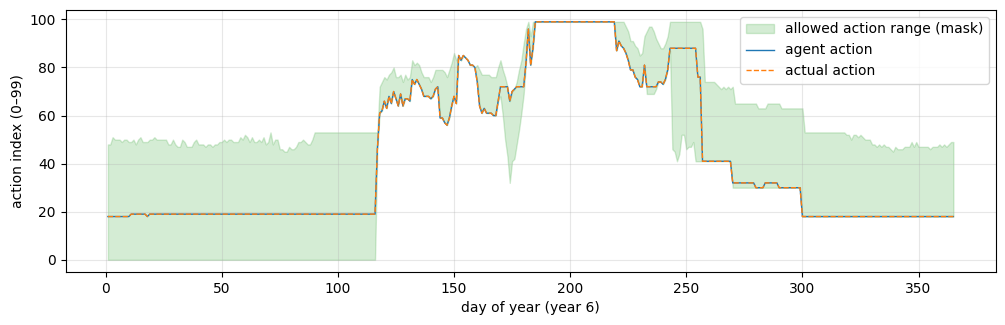

In [5]:
seg = daily[(daily.year == 5)]
fig, ax = plt.subplots()
ax.fill_between(seg.doy, seg.mask_min_action, seg.mask_max_action, color="tab:green", alpha=.2, label="allowed action range (mask)")
ax.plot(seg.doy, seg.agent_action, lw=1, label="agent action"); ax.plot(seg.doy, seg.actual_action, lw=1, ls="--", label="actual action")
ax.set_xlabel("day of year (year 6)"); ax.set_ylabel("action index (0–99)"); ax.legend(); ax.grid(alpha=.3)
print(f"action violation rate over 30 years: {daily.action_violation.mean()*100:.3f} %")
print(f"mean allowed actions per day        : {(daily.mask_max_action - daily.mask_min_action + 1).mean():.1f} / 100")

In [6]:
pen = ["power_reward", "level_penalty", "flood_penalty", "ecological_penalty", "powerlimit_penalty", "navigation_penalty", "action_penalty"]
daily[pen].describe().T[["mean", "min", "max"]].round(4)

,mean,min,max
power_reward,0.3158,0.0148,1.0
level_penalty,-0.0000,-0.0050,0.0
flood_penalty,-0.0064,-0.6569,0.0
ecological_penalty,0.0000,0.0000,0.0
powerlimit_penalty,0.0000,0.0000,0.0
navigation_penalty,-0.0006,-0.6024,0.0
action_penalty,-0.0009,-0.2449,0.0


## 2. Appendix E — 요약 시트

두 번째 시트에는 보상 계수 설정, 핵심 지표(발전량, 보증률, 위반율), 보상 구성요소 합계가 들어 있습니다.

In [7]:
summ = xl.parse(xl.sheet_names[1], header=None)
summ.columns = ["item", "value", "unit"]
LABELS = {"调度天数": "scheduling days", "总发电量": "total energy", "平均日发电量": "mean daily energy", "最大日发电量": "max daily energy", "最小日发电量": "min daily energy",
          "平均库容": "mean storage", "总弃水量": "total spill", "平均弃水量": "mean spill", "航运保证率": "navigation guarantee rate", "发电保证率": "power guarantee rate",
          "生态保证率": "ecological guarantee rate", "动作违规率": "action violation rate"}
kpi = summ[summ.item.isin(LABELS)].assign(item=lambda d: d.item.map(LABELS)).reset_index(drop=True)
kpi

,item,value,unit
0,scheduling days,10950,天
1,total energy,24998.73,亿kW·h
2,mean daily energy,2.28,亿kW·h
3,max daily energy,5.4,亿kW·h
4,min daily energy,1.22,亿kW·h
5,mean storage,288.95,亿m³
6,total spill,1492209.58,m³/s
7,mean spill,136.27,m³/s
8,navigation guarantee rate,99.88,%
9,power guarantee rate,100,%


## 3. Appendix F — 교차 저수지 검증 (Xiluodu, Xiangjiaba)

삼협에서 학습한 프레임워크를 다른 저수지에 적용한 5년(2020–2024) 로그입니다. 각 저수지가 별도 시트이고 `Summary` 시트에 집계가 있습니다.

In [8]:
COLS_F = ["date", "level_m", "tailwater_m", "storage_1e8m3", "inflow", "outflow", "turbine_flow", "spill_flow", "energy_1e8kWh", "water_balance", "agent_action", "actual_action",
          "power_reward", "ecological_penalty", "powerlimit_penalty", "action_penalty", "navigation_penalty", "ecological_violation", "powerlimit_violation", "navigation_violation"]
xf = pd.ExcelFile(APP_F)
logs = {}
for res in ("Xiluodu", "Xiangjiaba"):
    d = xf.parse(res)
    d.columns = COLS_F[:d.shape[1]]
    d["date"] = pd.to_datetime(d["date"]); logs[res] = d
print({k: v.shape for k, v in logs.items()}); logs["Xiluodu"].head(3)

{'Xiluodu': (1825, 20), 'Xiangjiaba': (1825, 20)}


,date,level_m,tailwater_m,storage_1e8m3,inflow,outflow,turbine_flow,spill_flow,energy_1e8kWh,water_balance,agent_action,actual_action,power_reward,ecological_penalty,powerlimit_penalty,action_penalty,navigation_penalty,ecological_violation,powerlimit_violation,navigation_violation
0,2020-01-01,600.0,376.15,115.74,2443.07,2443.07,2443.07,0.0,1.16,0,32,32,0.3832,0,0,0,0,0,0,0
1,2020-01-02,600.0,376.22,115.74,2493.46,2493.46,2493.46,0.0,1.18,0,33,33,0.3910,0,0,0,0,0,0,0
2,2020-01-03,600.0,376.47,115.74,2682.66,2682.66,2682.66,0.0,1.27,0,36,36,0.4202,0,0,0,0,0,0,0


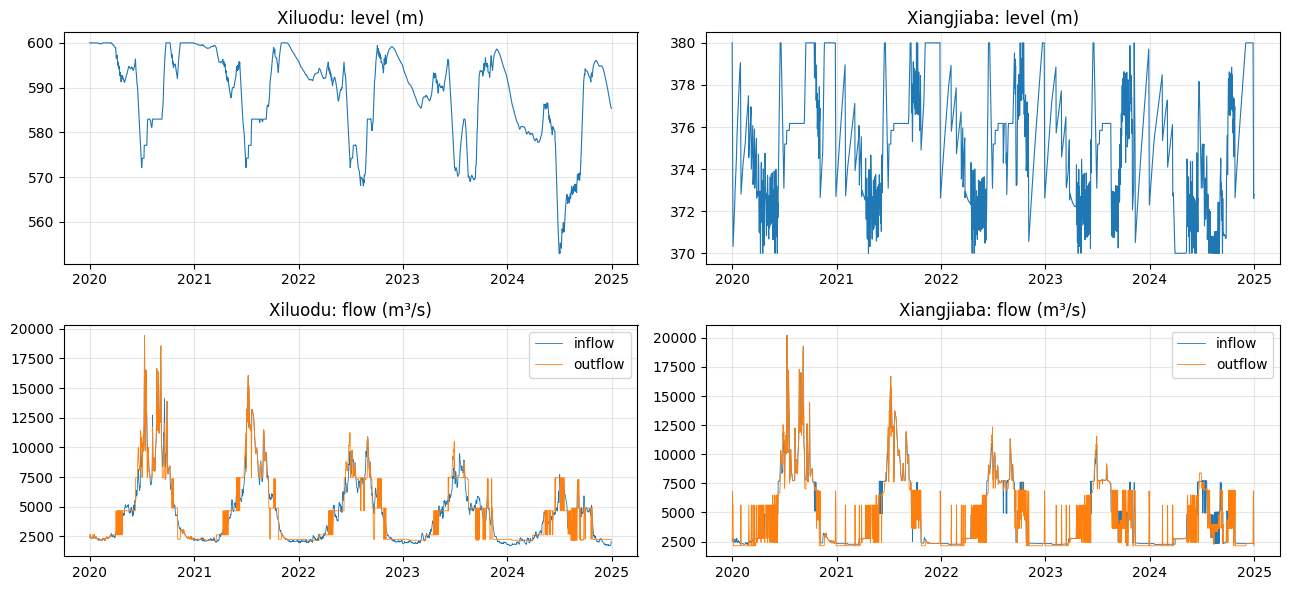

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for i, (res, d) in enumerate(logs.items()):
    axes[0, i].plot(d.date, d.level_m, lw=.8); axes[0, i].set_title(f"{res}: level (m)")
    axes[1, i].plot(d.date, d.inflow, lw=.6, label="inflow"); axes[1, i].plot(d.date, d.outflow, lw=.6, label="outflow"); axes[1, i].legend(); axes[1, i].set_title(f"{res}: flow (m³/s)")
for a in axes.ravel(): a.grid(alpha=.3)
plt.tight_layout()

In [10]:
summary_f = xf.parse("Summary", header=1)
summary_f.columns = ["reservoir", "total_energy_1e8kWh", "annual_energy_1e8kWh", "total_reward", "mean_reward", "mean_agent_action", "mean_actual_action",
                     "power_reward", "ecological_penalty", "powerlimit_penalty", "action_penalty", "navigation_penalty",
                     "ecological_violation_pct", "powerlimit_violation_pct", "navigation_violation_pct"][:summary_f.shape[1]]
summary_f

,reservoir,total_energy_1e8kWh,annual_energy_1e8kWh,total_reward,mean_reward,mean_agent_action,mean_actual_action,power_reward,ecological_penalty,powerlimit_penalty,action_penalty,navigation_penalty,ecological_violation_pct,powerlimit_violation_pct,navigation_violation_pct
0,Xiluodu,3267.19,653.44,1297.1446,0.7108,55.89,55.89,0.5920,0,0,0,0,0,0,0
1,Xiangjiaba,1646.74,329.35,1167.7812,0.6399,59.41,59.41,0.6268,0,0,0,0,0,0,0


In [11]:
xf.parse("Meta")

,field,value
0,source_file,evaluator_20260309_235457.xlsx
1,note,Public decision logs. Each reservoir uses a se...


## 정리

* Appendix E 는 `C2_Square` 정책이 30년 스트레스 시나리오에서 수위 범위, 보증출력, 생태·항운 유량을 거의 완벽히 지키면서 발전량을 확보하는 것을 보여줍니다. 액션 마스크가 허용 범위를 좁히고, 정책은 그 안에서 선택합니다.
* Appendix F 는 같은 프레임워크가 다른 저수지에도 위반 없이 적용됨을 보여줍니다.
* 튜토리얼의 toy 환경(노트북 02–04)은 이 로그의 열 이름과 같은 구조(`level, inflow, release, energy, cost_*`)를 쓰므로, 두 결과를 나란히 비교하며 해석할 수 있습니다.